# TP9 : Analyse de données - Évaluation

## Introduction

La supraconductivité est un phénomène physique où certains matériaux perdent toute résistance électrique en dessous d'une température critique. Ce phénomène a de nombreuses applications (IRM médicales, accélérateurs de particules, trains à lévitation magnétique), mais la plupart des supraconducteurs ne fonctionnent qu'à des températures extrêmement basses, ce qui limite leur utilisation pratique.

L'enjeu scientifique est donc de découvrir des matériaux supraconducteurs à température critique élevée. Pour cela, il faut comprendre comment les propriétés physico-chimiques d'un matériau influencent sa température critique.

### Les données

Le dataset contient 10,000 supraconducteurs décrits par :
- **81 features** : propriétés physico-chimiques incluant la composition atomique (nombre d'atomes de chaque élément), les propriétés atomiques moyennes (masse, rayon, électronégativité, valence, etc.), et des descripteurs structurels
- **1 target** : la température critique de supraconductivité (en Kelvin), variant de 0K à 185K

**Objectif du TP** : Explorer ces données pour comprendre visuellement et quantitativement comment les features expliquent la température critique.

---

**Bibliothèques autorisées** : Vous devez utiliser uniquement les bibliothèques listées ci-dessous. Aucune autre bibliothèque n'est autorisée pour ce TP.

In [10]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import Isomap
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

---

## Exercice 1 : Exploration des données

Chargez les données et réalisez une analyse descriptive et exploratoire. Identifiez au moins deux caractéristiques dans ces données qui pourraient influencervotre analyse par la suite.

**Barème** : /3

Dataset : (5000, 82)
Features : (5000, 81)
Températures : 5000
Valeurs nulles : 0
Stats températures :
count    5000.000000
mean       34.195541
std        34.174507
min         0.000325
25%         5.080000
50%        19.900000
75%        63.500000
max       136.000000
Name: critical_temperature, dtype: float64


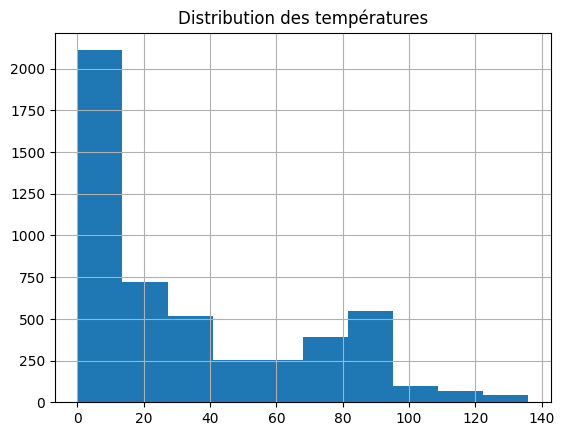

Corrélations négatives :
feature_73   -0.634139
feature_75   -0.616180
feature_72   -0.599909
feature_74   -0.571980
feature_34   -0.538732
Name: critical_temperature, dtype: float64
Corrélations positives :
feature_28              0.654294
feature_70              0.658426
feature_68              0.692058
feature_71              0.728347
critical_temperature    1.000000
Name: critical_temperature, dtype: float64


In [9]:
# On charge nos données mon fichier est nommée avec (2) car c'est la deuxieme version
dataset_pd = pd.read_csv("superconductivity_data (2).csv")
dataset = dataset_pd.to_numpy(dtype="float32")
n, m = dataset.shape

# On sépare nos features et notre target(qui correpond à la derniere colonne)
features = dataset[:, :-1]
nb_features = features.shape[1]
target = dataset[:, -1]
target_pd = dataset_pd.iloc[:, -1]

# On verifie les dimensions de notre dataset
print(f"Dataset : {dataset.shape}")
print(f"Features : {features.shape}")
print(f"Températures : {len(target)}")

# on check qu'il n'y ait pas de valeurs nulles dans le dataset (sinon ça serait inutile)
print(f"Valeurs nulles : {dataset_pd.isna().sum().sum()}")

# On visualise les premieres lignes de nos données
dataset_pd.head()

# On decrit les stats de la target qui est la temperature critique
print("Stats températures :")
print(target_pd.describe())

# J'ai choisi de faire un histogramme pour voir la distribution de la température critique
target_pd.hist()
plt.title("Distribution des températures")
plt.show()

# On regarde quelles features sont liées à la température critique
# c'est pour savoir lesquelles sont utiles pour prédire la température critique plus tard
correlations = dataset_pd.corr()['critical_temperature'].sort_values()

# on prend les 5 premières (plus fortes corrélations positives)
print("Corrélations négatives :")
print(correlations.head(5))

# et on prend aussi  les 5 dernières (plus fortes corrélations négatives)
print("Corrélations positives :")
print(correlations.tail(5))
#içi on ne veut juste pas les corrélation qui sont proches de 0 qui ne nous donnent pas d'informations

Dans l'histogramme on voit bien qu'il y a bien plus de matériaux avec une tres basse temperature que l'inverse. Le problème étant que si on fait une regression lineaire notre modèle sera bien entrainer sur les basses températures mais pas sur les hautes.

---

## Exercice 2 : Visualisation

Créez une visualisation 2D (nuage de points) qui représente au mieux les différences de température critique entre les supraconducteurs. Testez plusieurs approches et identifiez la meilleure.

**Barème** : /6

Nouvelle dimension : (5000, 2)
Variance expliquée : [0.38898933 0.10496573]
Variance totale : 0.49395508


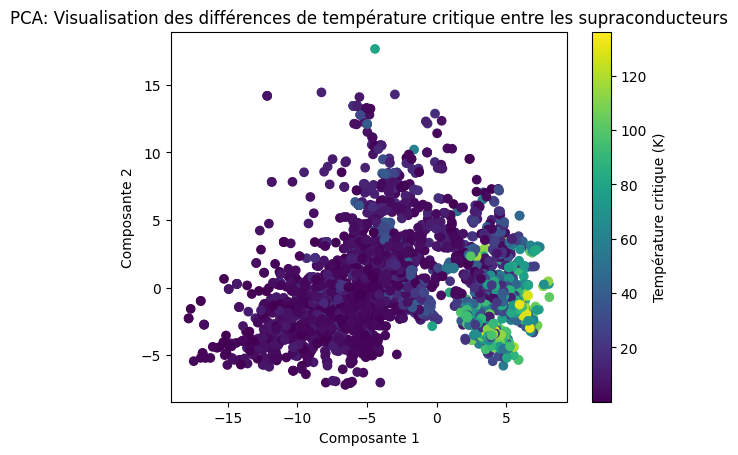

[[ 0.15635478 -0.05251474 -0.09858911 -0.08376615 -0.11995778  0.14734688
   0.1561195   0.12197805 -0.08524861  0.09472377  0.11123092  0.06131306
   0.13170968  0.02827782  0.12061311  0.15747474  0.11051451  0.16421665
   0.08446231  0.15571263  0.16407405 -0.02531559 -0.12197734 -0.08227363
  -0.1397967   0.15411687  0.16346698  0.16329357 -0.10075469  0.14962174
   0.16079566 -0.1097892  -0.13099378 -0.15127581 -0.15589945  0.12209779
   0.11559448  0.07080879 -0.0917839   0.03492953  0.06653157 -0.00629696
   0.0608462  -0.05478224  0.01382827  0.14060749  0.09671661  0.10361903
   0.06792365  0.09043035  0.10135663 -0.0948216  -0.09638947 -0.11916935
  -0.11534999  0.13342251  0.1427507  -0.00359323 -0.07519688 -0.0203584
  -0.00978667  0.05383007  0.02961221 -0.10773624 -0.10494911  0.03504184
  -0.00142975  0.141741    0.05905235  0.13268702  0.13753712 -0.13973932
  -0.14467652 -0.1412605  -0.14685762  0.15926504  0.15628542  0.02805726
  -0.10884251  0.0100228  -0.00186185]


In [ ]:
#On fait la pca en standardisant les données au préalable pour avoir tous les features à la meme echelle
#c'est pour pas qu'il y ait des features avec des poids trop grands.
pca = PCA(n_components=2)
scaler = StandardScaler()
features_standardises = scaler.fit_transform(features)

# on projette nos données
features_pca = pca.fit_transform(features_standardises)

#on vérifie bien que nos données ont bien été projeter
print("Nouvelle dimension :", features_pca.shape)

#On veut également voir si la PCA est utile si c'est le cas la somme des variances devraient être élévée
print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale :", sum(pca.explained_variance_ratio_))

#On crée notre visualisation avec un nuage de points

#scatter permet de réaliser le nuage de points
scatter = plt.scatter(features_pca[:, 0],features_pca[:, 1], c=target)

plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("PCA: Visualisation des différences de température critique entre les supraconducteurs")

#on ajoute une colorbar pour voir nos données en fonction de la température critique
plt.colorbar(scatter, label="Température critique (K)")
plt.show()

#on veut également savoir quels features composent nos composantes principales
#si un feature compte bien plus que les autres
print(pca.components_)



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 49 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-p

Nouvelle dimension Isomap : (5000, 2)


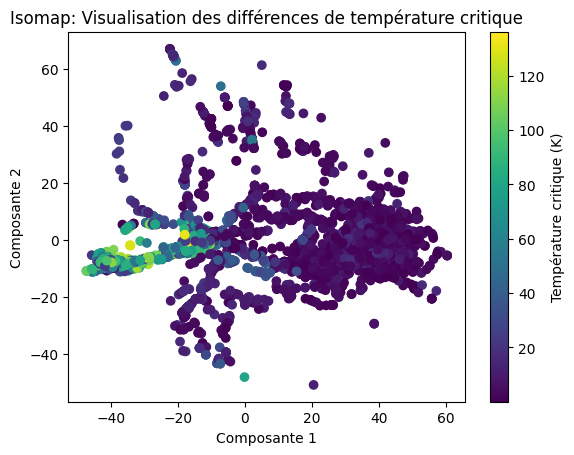

In [ ]:
#On fait également Isomap pour voir quelle approche est meilleur

# On applique Isomap en 2 dimensions
#les étapes sont les mêmes que celles faites plus hauts
isomap = Isomap(n_components=2)

supras_iso = isomap.fit_transform(features_standardises)

print("Nouvelle dimension Isomap :", supras_iso.shape)
plt.figure()

scatter = plt.scatter(supras_iso[:, 0], supras_iso[:, 1], c=target)

plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Isomap: Visualisation des différences de température critique")

plt.colorbar(scatter, label="Température critique (K)")

plt.show()


Pour la PCA:
- les deux premieres composantes expliquent environ 49% de la variance, ce qui veut dire qu'elles expliquent une bonne majorité de nos données
-On remarque qu'il n'y a pas vraimet de features principaux qui composent nos composantes principales, c'est plutot un mélange de tous.
-Pour le nuage de points, on voit bien une zone à droite dans laquelle les températures sont élevées. Il n'y a pas trop de dispersion.

Pour Isomap:

-Pour le nuage de points, les températures sont plus dispersées, plus mélangées.
-On voit également qu'il n'y a pas de zone clair, donc les différences de températures sont moins bien représentées.

J'ai choisi de plutot choisir la PCA et Isomap parce que c'est deux approchent qui permettent de projeter les données sur un espace de dimension inférieur. Kmeans permet de les regrouper en cluster et les modèles de régressions permettent de prédire (etudier l'overfitting ).
Dans cette question, on voit bien que la PCA est la meilleure approche puisque c'est celle où nos données sont le mieux représentées.

---

## Exercice 3 : Modélisation prédictive

Construisez un modèle de régression capable de prédire la température critique à partir des 81 features. Testez plusieurs approches et identifiez le meilleur modèle.

**Barème** : /6

In [ ]:
# 1) On sépare les données en train et test (80/20)
#le choix de 42 est seulement une réutilisation du tp8
np.random.seed(42)

indices = np.random.permutation(len(features_standardises))
split = int(0.8 * len(features_standardises))

train = indices[:split]
test = indices[split:]

Xtrain = features_standardises[train]
Xtest = features_standardises[test]

ytrain = target[train]
ytest = target[test]

# 2) Ridge avec plusieurs lambda pour ensuite déterminer lequel est optimal

lambdas = [0.1, 1, 10, 100, 1000]
mseridge = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    # on entraine nos donnéees
    ridge.fit(Xtrain, ytrain)

    pred = ridge.predict(Xtest)
    #on calcule le mean squared error pour ensuite comparer avec nos autres approches
    mse = np.mean((ytest - pred)**2)

    mseridge.append(mse)

    print("Ridge lambda =", lam, "MSE :", round(mse, 2))


# on cherche le meilleur lambda

bestlambda = lambdas[np.argmin(mseridge)]
bestmse = min(mseridge)

print("\nMeilleur lambda :", bestlambda)
print("Meilleur MSE Ridge :", round(bestmse, 2))


# 3) Regression lineaire (modele de base)

lr = LinearRegression()
# le modele apprend
lr.fit(Xtrain, ytrain)
# on fait les predictions
predlr = lr.predict(Xtest)
# calcul de l'erreur
mselr = np.mean((ytest - predlr)**2)
#j'ai mis round pour que ce soit plus lisible
print("Linear Regression MSE :", round(mselr, 2))



# 5) Comparaison des modeles

print("COMPARAISON :")
print("Linear Regression :", round(mselr, 2))
print("Ridge :", round(bestmse, 2))



# 6) On regarde le meilleur modele

resultats = {"Linear Regression": mselr,"Ridge": bestmse,}
#on ne renvoie pas directement le min la key correspondante pour la lisibilité
meilleur = min(resultats, key=resultats.get)

print("Meilleur modele :", meilleur)

Ridge lambda = 0.1 MSE : 327.89
Ridge lambda = 1 MSE : 331.23
Ridge lambda = 10 MSE : 342.34
Ridge lambda = 100 MSE : 369.89
Ridge lambda = 1000 MSE : 417.96

Meilleur lambda : 0.1
Meilleur MSE Ridge : 327.89
Linear Regression MSE : 327.43
COMPARAISON :
Linear Regression : 327.43
Ridge : 327.89
Meilleur modele : Linear Regression


je n'ai pas eu le temps de décrire nos résultat mais le meilleur modèle obtenu est la regression linéaire

---

## Critères d'évaluation généraux

Votre travail sera évalué sur :

**Rigueur méthodologique** :
- Justification de tous vos choix (méthodes, paramètres, prétraitements)
- Méthodologie d'évaluation appropriée (séparation train/test, validation, métriques)
- Documentation claire de votre démarche

**Exploration et créativité** :
- Variété des approches testées (vous devez tester plusieurs méthodes/paramètres/prétraitements)
- Capacité à proposer et justifier vos propres critères d'évaluation
- Esprit critique sur les résultats obtenus

**Communication** :
- Code clair, commenté et bien organisé
- Tableaux comparatifs de vos différentes approches
- Synthèses concises expliquant vos conclusions

**Important** : Une approche rigoureuse et bien documentée vaut mieux qu'une approche complexe mal justifiée. Expliquez vos choix, comparez vos résultats, et soyez critiques.

**Attention** : L'utilisation de chatbots type ChatGPT est complètement interdite et sera fortement sanctionnée. J'ai été assez clément jusqu'ici mais je vous assure que cela se voit facilement lorsque vous copiez-collez du code ou du texte dans vos TP.

**Barème** : /5